
<h1><b><p style="background-image: url(https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS_i55GJPQukV5qBic4yhFxHSJaE3pBgicerQ&s);font-family:tahoma;font-size:150%;color:Navy;text-align:center;border-radius:15px 50px; padding:7px; border:solid 2px #09375b; box-shadow: 10px 10px 10px #042b4c">Telco <span style="color: red;">Customer </span> Churn</p></b></h1>

<img src="https://img.freepik.com/premium-photo/people-figures-with-comment-clouds-their-heads-social-communication-information-exchange_1048944-21824983.jpg?size=626&ext=jpg&uid=R143520149&ga=GA1.1.830550831.1709345650&semt=ais" style="width:90%">


<h1 style="font-family: 'poppins'; font-weight:bold ; color: Navy;">
    <span style="color: red;">Author : </span>Danish Mubashar
</h1>
<h1 style="font-family: 'poppins'; font-weight:bold ; color: Navy;">
    <span style="color: red;">Co-Author : </span>
    <a href="https://www.kaggle.com/ibrahimqasimi" target="_blank">Muhammad Ibrahim Qasmi</a>
</h1>
<h1 style="font-family: 'poppins'; font-weight:bold ; color: Navy;">
    <span style="color: red;">Dataset : </span>Telco Customer Churn
</h1>
<h1 style="font-family: 'poppins'; font-weight:bold ; color: Navy;">
    <span style="color: red;">Date : </span>07 Apr 2024
</h1>

<h3 style="font-family: 'poppins'; font-weight:bold ; color: Navy;">
    Hi 👋 everyone! Welcome to my notebook. 📓 I'm passionate about data science, and I'm excited to share my findings with you. 🤓 
    In my recent notebook, I successfully implemented <span style="color: red;">Telco Customer Churn</span>. 
    If you find this notebook helpful, please <span style="color: red;">|| UPVOTE ||</span> ❤️
</h3>


<h2 style="font-family: 'poppins'; font-weight:bold ; color: Navy;"><span style="color: red;">About Dataset : </span> </h2>
<h2 style="font-family: 'poppins'; font-weight:bold ; color: Navy;"><span style="color: red;">Context </span> </h2>
<h5 style="font-family: 'poppins'; font-weight:bold ; color: Navy;"><span style="color: red;"> </span>"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets] </h5>

<h2 style="font-family: 'poppins'; font-weight:bold ; color: Navy;"><span style="color: red;">Content</span> </h2>
<h5 style="font-family: 'poppins'; font-weight:bold ; color: Navy;"><span style="color: red;"></span> Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

* Customers who left within the last month – the column is called Churn
* Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
* Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
* Demographic info about customers – gender, age range, and if they have partners and dependents</h5>


<a id="1"></a>
<h1><b><p style="background-image: url(https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS_i55GJPQukV5qBic4yhFxHSJaE3pBgicerQ&s);font-family:tahoma;font-size:120%;color:Navy;text-align:center;border-radius:15px 50px; padding:7px; border:solid 2px #09375b; box-shadow: 10px 10px 10px #042b4c">Libraries</p></b></h1>

In [1]:
# 1. to handle the data
import pandas as pd
import numpy as np
from scipy import stats

# to visualize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# import iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#for classification tasks
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
# pipeline
from sklearn.pipeline import Pipeline
# metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error,mean_squared_error,r2_score

# ignore warnings   
import warnings
warnings.filterwarnings('ignore')

<a id="1"></a>
<h1><b><p style="background-image: url(https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS_i55GJPQukV5qBic4yhFxHSJaE3pBgicerQ&s);font-family:tahoma;font-size:120%;color:Navy;text-align:center;border-radius:15px 50px; padding:7px; border:solid 2px #09375b; box-shadow: 10px 10px 10px #042b4c">Read Data</p></b></h1>

In [2]:
# load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
# print all column
pd.set_option('display.max_columns', None)
# print first 3 rows
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


<a id="1"></a>
<h1><b><p style="background-image: url(https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS_i55GJPQukV5qBic4yhFxHSJaE3pBgicerQ&s);font-family:tahoma;font-size:120%;color:Navy;text-align:center;border-radius:15px 50px; padding:7px; border:solid 2px #09375b; box-shadow: 10px 10px 10px #042b4c">EDA</p></b></h1>

<h3 style="font-family: 'poppins'; font-weight: bold; color: red;">Balance of Data :)</h3>


In [3]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

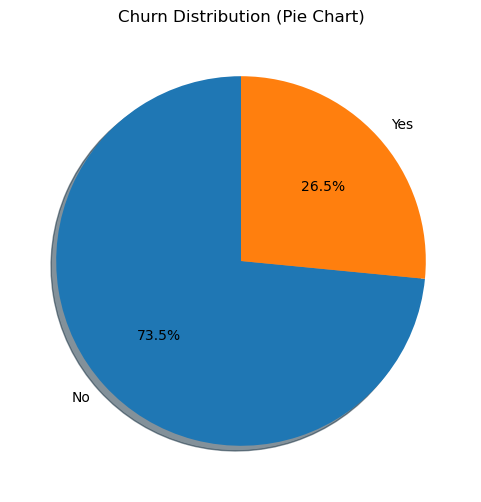

In [4]:
# Count values
churn_counts = df['Churn'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',      
    startangle=90,
    shadow=True             
)

plt.title("Churn Distribution (Pie Chart)")
plt.show()


<h5 style="font-family: 'poppins'; font-weight:bold; color: Navy;">
The Churn column is highly imbalanced where <span style="color: red;">5174</span> customers did <span style="color: red;">not churn</span> and only <span style="color: red;">1869</span> customers <span style="color: red;">churned</span>.
</h5>

<h5 style="font-family: 'poppins'; font-weight:bold; color: Navy;">
This imbalance shows that the dataset has significantly more <span style="color: red;">No</span> class than <span style="color: red;">Yes</span>, which can negatively affect model performance and requires balancing techniques.
</h5>


<h3 style="font-family: 'poppins'; font-weight: bold; color: red;">Info Of Columns :)</h3>


In [5]:
# check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


  * <h5 style="font-family: 'poppins'; font-weight:bold; color: Navy;"> By Using Info Function We Can See Count Of Columns And Rows DataType Of Data And Missing Values Also.In The Data <span style="color: red;">2</span> Columns Are of Int datatype And <span style="color: red;">1</span> Float Datatype And <span style="color: red;">18</span> Are Object Datatype . </h5>
  * <h5 style="font-family: 'poppins'; font-weight:bold; color: Navy;"> In The Data <span style="color: red;">7043</span> Rows And <span style="color: red;">21</span> Columns . </h5>
  *  <h5 style="font-family: 'poppins'; font-weight:bold; color: Navy;"> In The Data <span style="color: red;">2</span> Columns Are of <span style="color: red;">Int</span> datatype <span style="color: red;">1</span> Column <span style="color: red;">Float</span> Datatype And <span style="color: red;">18</span> Columns Are <span style="color: red;">Object</span> Datatype .  </h5>
  *    <h5 style="font-family: 'poppins'; font-weight:bold; color: Navy;"> In The Data <span style="color: red;">TotalCharges</span> Column Is <span style="color: red;">Float</span> Datatype But It Show <span style="color: red;">Object</span> Datatype  </h5>

In [6]:
df[df['TotalCharges'].str.strip() == ""][['customerID', 'TotalCharges']]


,customerID,TotalCharges
488,4472-LVYGI,
753,3115-CZMZD,
936,5709-LVOEQ,
1082,4367-NUYAO,
1340,1371-DWPAZ,
3331,7644-OMVMY,
3826,3213-VVOLG,
4380,2520-SGTTA,
5218,2923-ARZLG,
6670,4075-WKNIU,


* <h5 style="font-family: 'poppins'; font-weight:bold; color: Navy;"> These <span style="color: red;">11</span> Rows In The <span style="color: red;">TotalCharges</span> Column Are Completely Blank (<span style="color: red;">""</span>) Because These Customers Have <span style="color: red;">Tenure = 0</span> And Haven’t Been Billed Yet. </h5>
* <h5 style="font-family: 'poppins'; font-weight:bold; color: Navy;"> After Converting <span style="color: red;">TotalCharges</span> To Numeric, These Blanks Become <span style="color: red;">NaN</span>, Creating Missing Values In The Dataset. </h5>


In [7]:
# Before 
print("Before:", df['TotalCharges'].dtype)
# Convert datatype for 'TotalCharges'
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# After 
print("After:", df['TotalCharges'].dtype)

Before: object
After: float64


<h3 style="font-family: 'poppins'; font-weight: bold; color: red;">Check Missing Values :)</h3>


In [8]:
print(df.isnull().sum().sort_values(ascending=False))

TotalCharges        11
customerID           0
DeviceProtection     0
MonthlyCharges       0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
OnlineBackup         0
gender               0
OnlineSecurity       0
InternetService      0
MultipleLines        0
PhoneService         0
tenure               0
Dependents           0
Partner              0
SeniorCitizen        0
Churn                0
dtype: int64


In [9]:
# remove id column
df = df.drop(columns=['customerID'])
# remove missing values
df.dropna(inplace=True)

In [10]:
print(df.isnull().sum().sort_values(ascending=False))

gender              0
SeniorCitizen       0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
DeviceProtection    0
OnlineBackup        0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
Churn               0
dtype: int64


<h3 style="font-family: 'poppins'; font-weight: bold; color: red;">Summary Of Numerical Columns :)</h3>


In [11]:
# summary dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


<h3 style="font-family: 'poppins'; font-weight: bold; color: red;">Check Unique Values :)</h3>


In [12]:
# apply loop check unique value without int or float in dataset
for col in df.columns:
    if df[col].dtype != 'int64' and df[col].dtype != 'float64':
        print(f'{col} : {df[col].unique()}')

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


<h3 style="font-family: 'poppins'; font-weight: bold; color: red;">Visualization :)</h3>


<h5 style="font-family: 'poppins'; font-weight:bold ; color: Navy;"> In This Dataset  <span style="color: red;">85.71%</span> Is Data Object DataType  And <span style="color: red;">14.29%</span>iIs Numerical Data  || I Used <span style="color: red; font-size: 25px;font-weight:bold ">Count Plot</span>
 For Describe These Object Columns With Respect To <span style="color: red;font-weight:bold">Churn</span> Column </h5>


 <h5 style="font-family: 'poppins'; font-weight:bold; color: Navy;">  <span style="color: red;">Customer Churn</span>  "Customer Churn" is a binary concept, meaning customers either churn (leave or stop doing business with a company) or they don't. It is a simple yes or no question – either a customer has churned or they have not </h5>

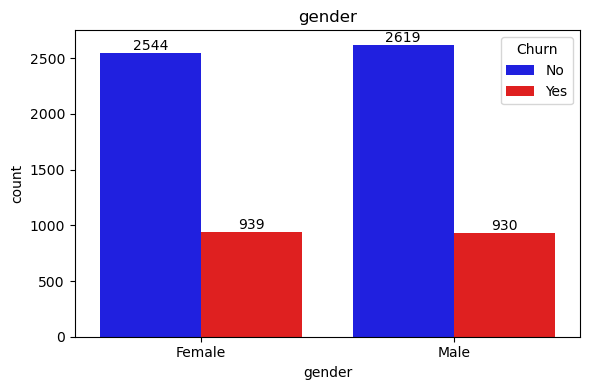

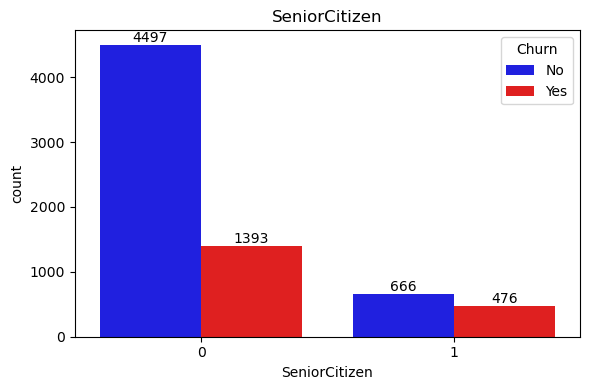

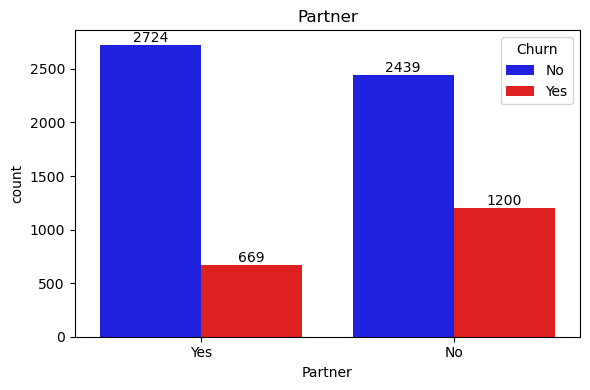

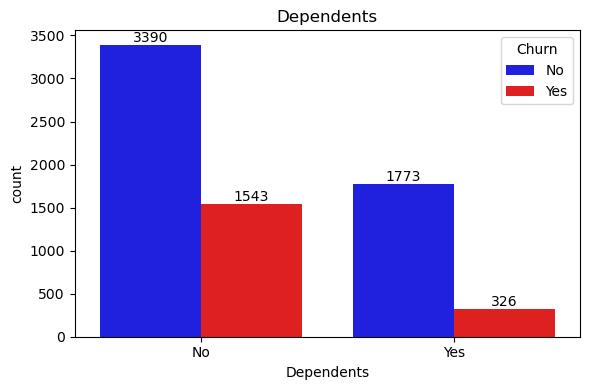

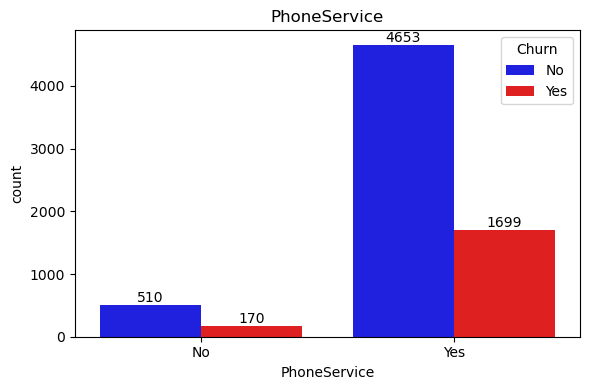

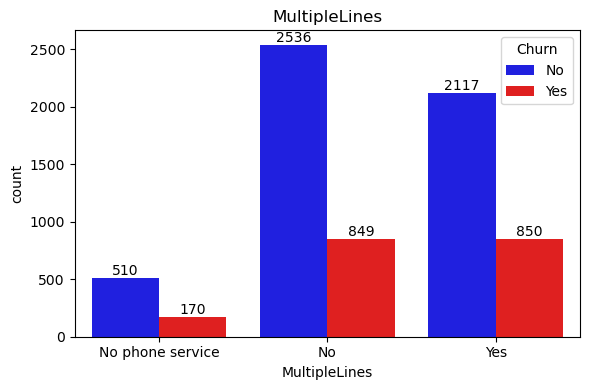

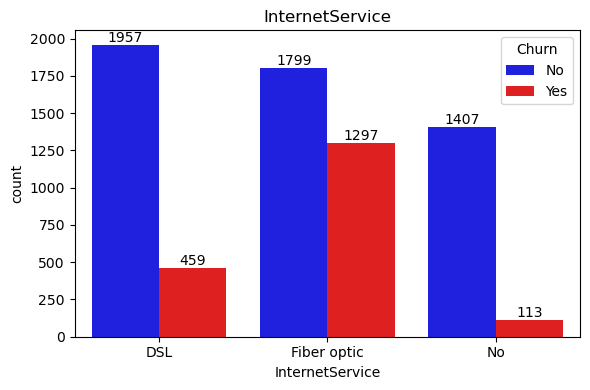

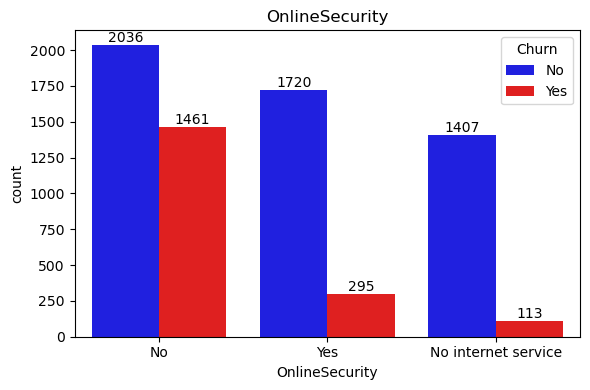

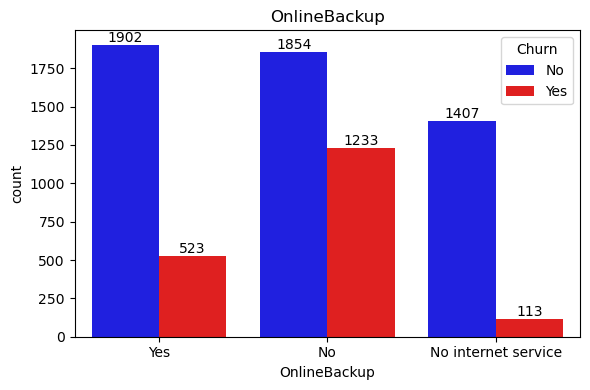

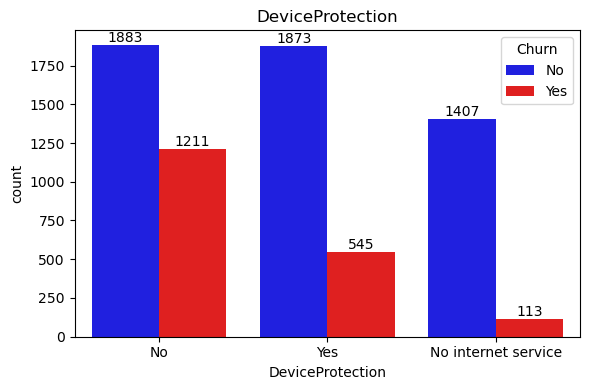

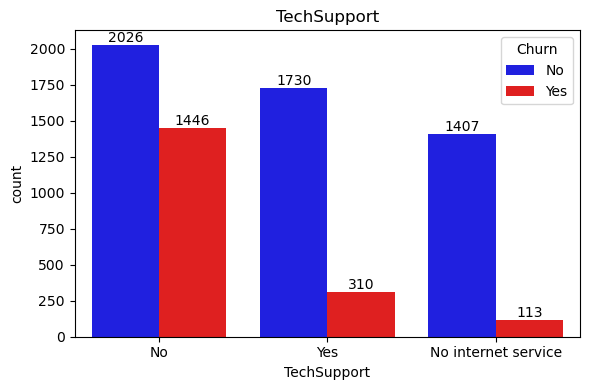

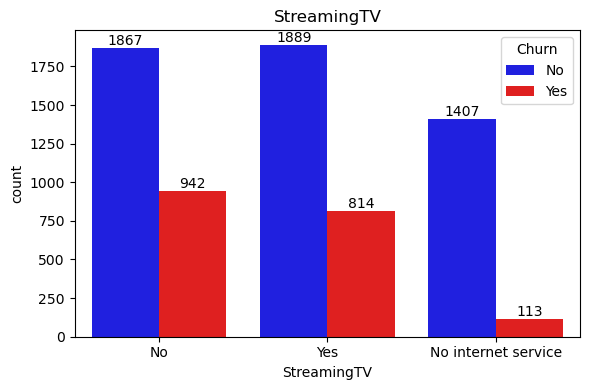

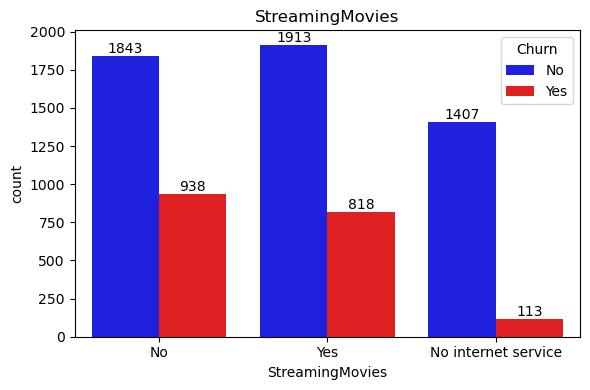

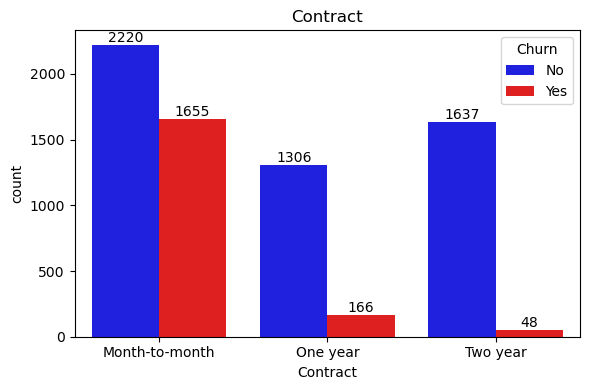

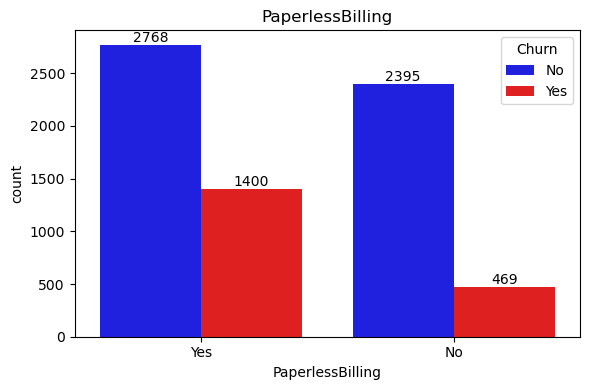

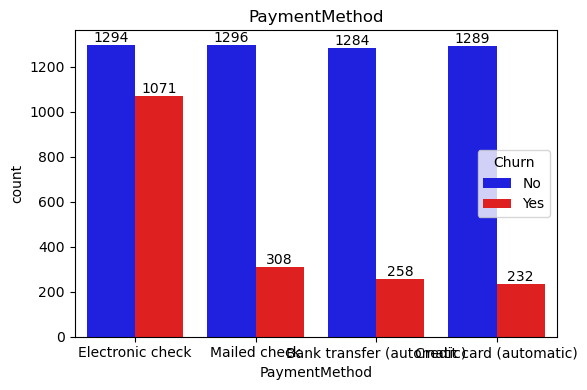

In [13]:
# colors for Yes and No
colors = {'Yes': 'red', 'No': 'blue'}

for i, predictor in enumerate(df.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges', 'tenure'])):
    plt.figure(i, figsize=(6, 4))
    ax = sns.countplot(data=df, x=predictor, hue='Churn', palette=colors)
    plt.title(predictor)
    
    # Add values on top of each bar
    for container in ax.containers:
        ax.bar_label(container)
    
    plt.tight_layout()
    plt.show()


<h3 style="font-family: 'poppins'; font-weight: bold; color: red;">Numerical Data :)</h3>


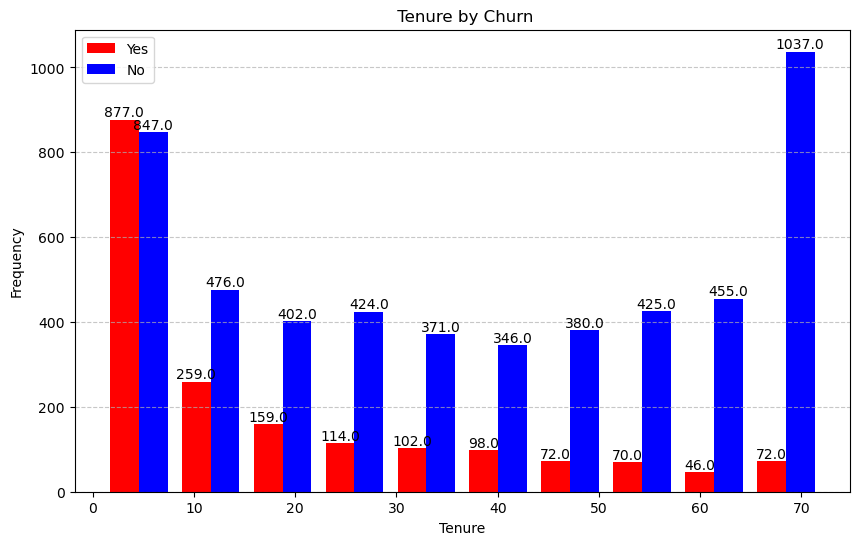

In [14]:
# make plot for tenure
churned = df[df['Churn'] == 'Yes']
not_churned = df[df['Churn'] == 'No']

# Plotting
plt.figure(figsize=(10, 6))
plt.hist([churned['tenure'], not_churned['tenure']], bins=10, color=['red', 'blue'], label=['Yes', 'No'])
plt.title(' Tenure by Churn')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text on top of bars
for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')


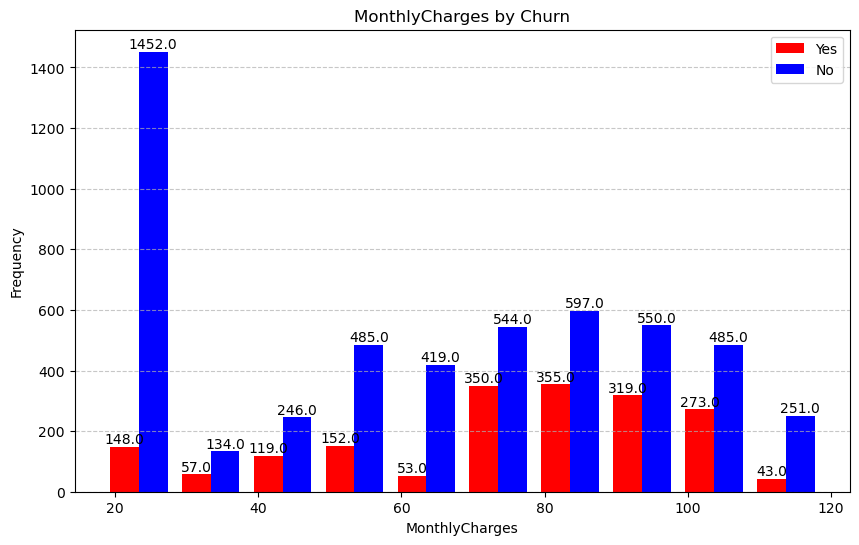

In [15]:
# make plot for MonthlyCharges
churned = df[df['Churn'] == 'Yes']
not_churned = df[df['Churn'] == 'No']

# Plotting
plt.figure(figsize=(10, 6))
plt.hist([churned['MonthlyCharges'], not_churned['MonthlyCharges']], bins=10, color=['red', 'blue'], label=['Yes', 'No'])
plt.title('MonthlyCharges by Churn')
plt.xlabel('MonthlyCharges')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text on top of bars
for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')


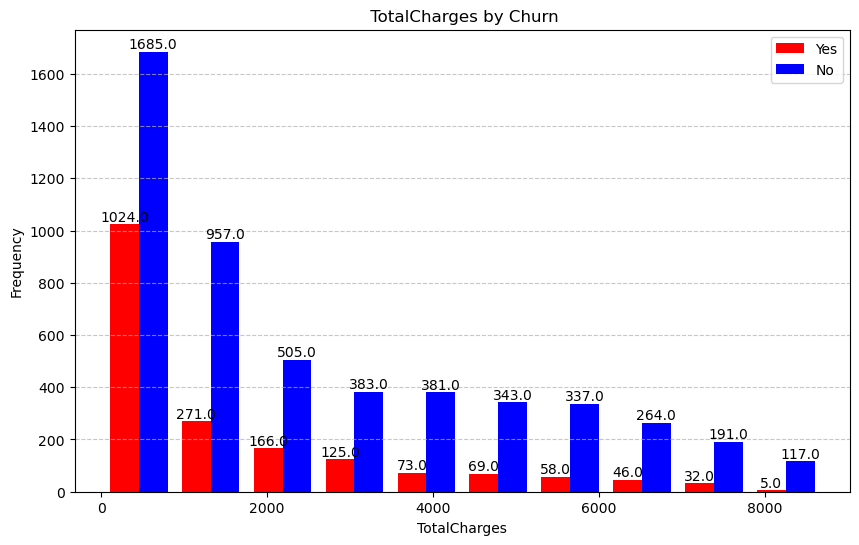

In [16]:
# make plot for tenure
churned = df[df['Churn'] == 'Yes']
not_churned = df[df['Churn'] == 'No']

# Plotting
plt.figure(figsize=(10, 6))
plt.hist([churned['TotalCharges'], not_churned['TotalCharges']], bins=10, color=['red', 'blue'], label=['Yes', 'No'])
plt.title(' TotalCharges by Churn')
plt.xlabel('TotalCharges')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text on top of bars
for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')


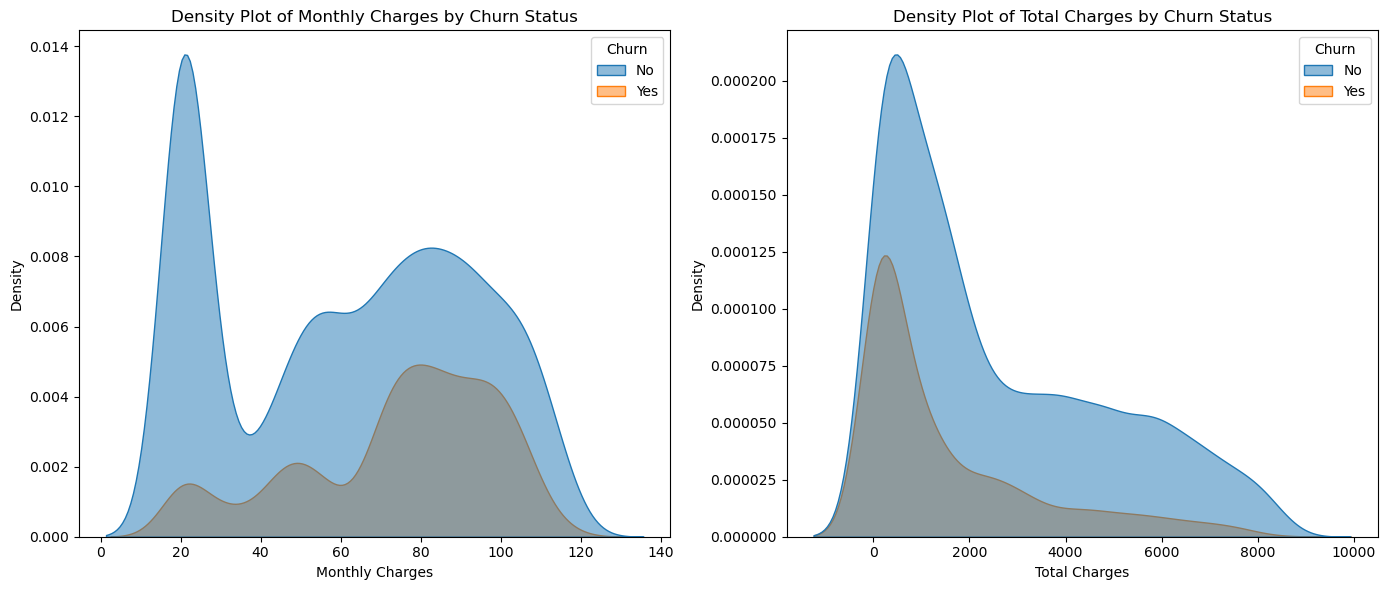

In [17]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Monthly Charges
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, alpha=0.5, ax=axes[0])
axes[0].set_title('Density Plot of Monthly Charges by Churn Status')
axes[0].set_xlabel('Monthly Charges')
axes[0].set_ylabel('Density')

# Plot for Total Charges
sns.kdeplot(data=df, x="TotalCharges", hue="Churn", fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title('Density Plot of Total Charges by Churn Status')
axes[1].set_xlabel('Total Charges')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()


<a id="1"></a>
<h1><b><p style="background-image: url(https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcS_i55GJPQukV5qBic4yhFxHSJaE3pBgicerQ&s);font-family:tahoma;font-size:120%;color:Navy;text-align:center;border-radius:15px 50px; padding:7px; border:solid 2px #09375b; box-shadow: 10px 10px 10px #042b4c">Machine Learning</p></b></h1>

<h3 style="font-family: 'poppins'; font-weight: bold; color: red;">Models :)</h3>


<h4 style="font-family: 'poppins'; font-weight:bold ; color: Navy;">Encode The Data By OneHotEncoder</h4>


In [18]:

# Encode target column 'Churn' using LabelEncoder
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

# Identify categorical columns (excluding target)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

# One-Hot Encode categorical features
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [19]:
# Split dataset into X and y

X = df.drop('Churn', axis=1)  # Features
y = df['Churn']               # Target

print("X shape:", X.shape)
print("y shape:", y.shape)
# data into train and split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

X shape: (7032, 30)
y shape: (7032,)


In [21]:
# Initialize an empty list to store model scores
model_scores = []

# Create a list of models to evaluate
models = [
    ('Random Forest', RandomForestClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__max_depth': [None, 10, 20]}),  # Add hyperparameters for Random Forest
    ('Gradient Boosting', GradientBoostingClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__learning_rate': [0.05, 0.1, 0.5]}),  # Add hyperparameters for Gradient Boosting
    ('Support Vector Machine', SVC(random_state=42, class_weight='balanced'),
        {'model__C': [0.1, 1, 10],
         'model__gamma': ['scale', 'auto']}),  # Add hyperparameters for SVM
    ('Logistic Regression', LogisticRegression(random_state=42, class_weight='balanced'),
        {'model__C': [0.1, 1, 10],
         'model__penalty': ['l1', 'l2']}),  # Add hyperparameters for Logistic Regression
    ('K-Nearest Neighbors', KNeighborsClassifier(),
        {'model__n_neighbors': [3, 5, 7],
         'model__weights': ['uniform', 'distance']}),  # Add hyperparameters for KNN
    ('Decision Tree', DecisionTreeClassifier(random_state=42),
        {'model__max_depth': [None, 10, 20],
         'model__min_samples_split': [2, 5, 10]}),  # Add hyperparameters for Decision Tree
    ('Ada Boost', AdaBoostClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__learning_rate': [0.05, 0.1, 0.5]}),  # Add hyperparameters for Ada Boost
    ('XG Boost', XGBClassifier(random_state=42),
        {'model__n_estimators': [50, 100, 200],
         'model__learning_rate': [0.05, 0.1, 0.5]}),  # Add hyperparameters for XG Boost
    ('Naive Bayes', GaussianNB(), {})  # No hyperparameters for Naive Bayes
]

best_model = None
best_accuracy = 0.0

# Iterate over the models and evaluate their performance
for name, model, param_grid in models:
    # Create a pipeline for each model
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),  # Feature Scaling
        ('model', model)
    ])

    # Hyperparameter tuning using GridSearchCV
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=2)
        grid_search.fit(X_train, y_train)
        pipeline = grid_search.best_estimator_

    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = pipeline.predict(X_test)

    # Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)

    # Append model name and accuracy to the list
    model_scores.append({'Model': name, 'Accuracy': accuracy})

    # Convert the list to a DataFrame
    scores_df = pd.DataFrame(model_scores)
    # Print the performance metrics
    print("Model:", name)
    print("Test Accuracy:", round(accuracy, 3),"%")
    print()

    # Check if the current model has the best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline

# Retrieve the overall best model
print("Best Model:")
print("Test Accuracy:", best_accuracy)
print("Model Pipeline:", best_model, "with accuracy", round(best_accuracy, 2), "%")

Model: Random Forest
Test Accuracy: 0.788 %

Model: Gradient Boosting
Test Accuracy: 0.798 %

Model: Support Vector Machine
Test Accuracy: 0.725 %

Model: Logistic Regression
Test Accuracy: 0.726 %

Model: K-Nearest Neighbors
Test Accuracy: 0.755 %

Model: Decision Tree
Test Accuracy: 0.75 %

Model: Ada Boost
Test Accuracy: 0.795 %

Model: XG Boost
Test Accuracy: 0.797 %

Model: Naive Bayes
Test Accuracy: 0.645 %

Best Model:
Test Accuracy: 0.7981520966595593
Model Pipeline: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('model',
                 GradientBoostingClassifier(n_estimators=50, random_state=42))]) with accuracy 0.8 %


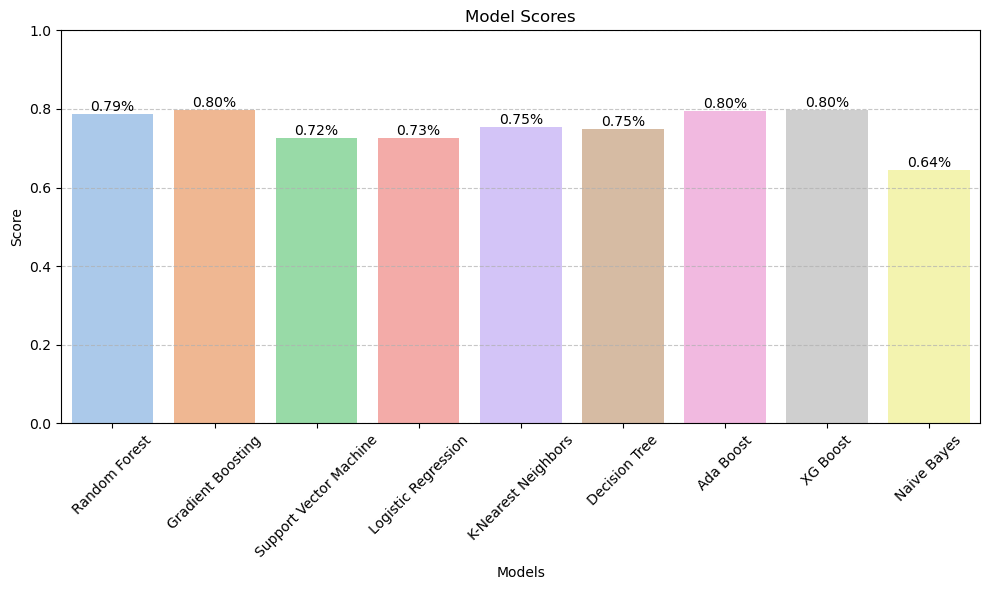

In [22]:
# Define a color palette for the bars
colors = sns.color_palette('pastel', n_colors=len(scores_df))

# Create a bar plot of models and their scores
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Accuracy', data=scores_df, palette=colors)

# Add text on each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Model Scores')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<img src="https://img.freepik.com/free-vector/thank-you-lettering_1262-6963.jpg?size=626&ext=jpg&ga=GA1.1.735520172.1710633600&semt=ais" width="1000">